In [1]:
%pip install opencv-python-headless

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os 
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_dir = r'drive-download-20240709T132713Z-001/Training'

imgDetails  = []

In [4]:
for className in os.listdir(input_dir):
    classPath = os.path.join(input_dir, className)

    for imageName in os.listdir(classPath):
        imagePath = os.path.join(classPath, imageName)

        image = cv2.imread(imagePath)

        if image is not None:
            height, width,channels = image.shape
            imageType = image.dtype
            resolution = (height, width)

            imgDetails.append({
                'imageName' : imageName,
                'class' : className,
                'height': height,
                'width' : width,
                'channels' : channels,
                'type' : imageType,
                'resolution' : resolution,
                'path' : imagePath
            })

imageDf = pd.DataFrame(imgDetails)

imageDf.to_csv('imgDetails.csv', index=False)

In [5]:
#Analysis Data Set 

print("Number of images:" , len(imageDf))
print("Image classes", imageDf['class'].unique())
print("Average image resolution", imageDf[['height', 'width']].mean())
print("Image types", imageDf['type'].unique())

Number of images: 3659
Image classes ['High' 'Empty' 'Low' 'Traffic Jam' 'Medium']
Average image resolution height    403.249522
width     610.744739
dtype: float64
Image types [dtype('uint8')]


In [6]:
#Class Specific analysis 

for className in imageDf['class'].unique():
    classDf = imageDf[imageDf['class']== className]
    print(f"\nClass: {className}")
    print(f"Number of images: {len(classDf)}")
    print(f"Average heigth: {classDf['height'].mean()}")
    print(f"Average width: {classDf['width'].mean()}")
    print(f"Height Variance is : {np.var(classDf['height'])}")
    print(f"Width Variance is : {np.var(classDf['width'])}")
    


Class: High
Number of images: 434
Average heigth: 445.5184331797235
Average width: 639.8364055299539
Height Variance is : 3742.3510427063734
Width Variance is : 1622.049273715714

Class: Empty
Number of images: 1249
Average heigth: 371.2409927942354
Average width: 558.7830264211369
Height Variance is : 8532.086838405878
Width Variance is : 19393.234747926635

Class: Low
Number of images: 987
Average heigth: 395.258358662614
Average width: 632.5430597771024
Height Variance is : 3658.9758039928906
Width Variance is : 2330.6149138393944

Class: Traffic Jam
Number of images: 248
Average heigth: 454.44354838709677
Average width: 650.5685483870968
Height Variance is : 61230.25487773148
Width Variance is : 139140.7049785381

Class: Medium
Number of images: 741
Average heigth: 425.95546558704456
Average width: 638.9271255060729
Height Variance is : 3666.568866888519
Width Variance is : 307.654608336474


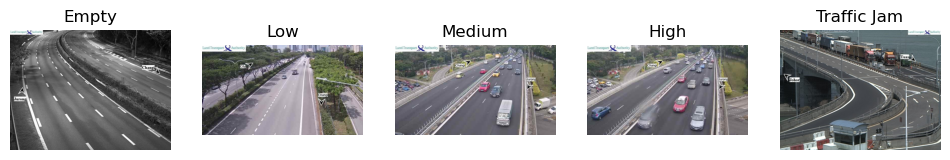

In [7]:
#visualising the data set given 

classCounts = imageDf['class'].value_counts()

plt.figure(figsize=(12,8))

for i, (className, count) in enumerate(classCounts.items()):
    if i>=5:
        break
    exampleImagePath = os.path.join(input_dir, className, os.listdir(os.path.join(input_dir, className))[0])
    
    exampleImage = cv2.imread(exampleImagePath)
    exampleImage = cv2.cvtColor(exampleImage, cv2.COLOR_BGR2RGB)


    plt.subplot(1,5,i+1)
    plt.imshow(exampleImage)
    plt.title(className)
    plt.axis('off')
plt.show()


In [8]:
%pip install opencv-python numpy tqdm scikit-image


Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install scikit-image


Note: you may need to restart the kernel to use updated packages.


In [10]:
import os 
import cv2
import numpy as np 
from tqdm import tqdm
from skimage import feature


In [11]:
# def preImage(imagePath, outputPath, size=(224,224)):
#     """
#     Preprocess a single image by resizing, normalizing, and applying edge detection.

#     Parameters:
#     - image_path: str, path to the input image.
#     - output_path: str, path to save the preprocessed image.
#     - size: tuple, size to resize the image (default is (224, 224)).
#     """


#     img = cv2.imread(imagePath)
#     if img is None:
#         return
    
#     imgResize = cv2.resize(img,size,interpolation=cv2.INTER_AREA)
#     imgGray = cv2.cvtColor(imgResize, cv2.COLOR_BGR2GRAY)
#     imgNormalized = imgGray/255.0   #normalizing to increase the contrast of the image 

#     edge = feature.canny(imgNormalized, sigma=1)

#     cv2.imwrite(outputPath, (edge * 255).astype(np.uint8))



In [15]:
def preImage(image_path, output_path, size=(224, 224)):
    """
    Preprocess a single image by resizing, normalizing, and converting to grayscale.

    Parameters:
    - image_path: str, path to the input image.
    - output_path: str, path to save the preprocessed image.
    - size: tuple, size to resize the image (default is (224, 224)).
    """
    # Load the image from the given path
    img = cv2.imread(image_path)
    if img is None:
        return  # If image can't be loaded, exit the function

    # Resize the image to the given size
    img_resized = cv2.resize(img, size, interpolation=cv2.INTER_AREA)

    # Convert the image to grayscale
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Normalize the pixel values to range between 0 and 1
    img_normalized = img_gray / 255.0

    # Save the preprocessed image
    cv2.imwrite(output_path, (img_normalized * 255).astype(np.uint8))

In [16]:
def preData(input_dir, outputPath, size = (224,224)):
    """
    Preprocess all images in the dataset directory.

    Parameters:
    - input_dir: str, path to the input dataset directory.
    - output_dir: str, path to save the preprocessed dataset.
    - size: tuple, size to resize the images (default is (224, 224)).
    """

    if not os.path.exists(outputPath):
        os.makedirs(outputPath)

    classes = ['Empty', 'High','Low','Medium', 'Traffic Jam']

    for className in classes:
        inputClassDir = os.path.join(input_dir, className)
        outputClassDir = os.path.join(outputPath, className)

        if not os.path.exists(outputClassDir):
            os.makedirs(outputClassDir)

        if not os.path.exists(inputClassDir):
            print(f"Directory {inputClassDir} does not exitst skipping...")
            continue

        for imageName in tqdm(os.listdir(inputClassDir), desc=f'Preprocessing {className}'):
            inputImagePath = os.path.join(inputClassDir, imageName)
            outputImagePath = os.path.join(outputClassDir, imageName)
            preImage(inputImagePath, outputImagePath, size)


In [17]:
if __name__ =='__main__':
    input_dir = r'drive-download-20240709T132713Z-001/Training'
    outputPath = r'preprocessed data'
    preData(input_dir, outputPath)

Preprocessing Traffic Jam: 100%|██████████| 248/248 [00:01<00:00, 131.81it/s]


Implementation of model 


In [18]:
%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt



In [3]:
basePath = 'preprocessed data'

classes = ['Empty', 'High', 'Low', 'Medium', 'Traffic Jam']

dataGen = ImageDataGenerator(rescale=1./255) # type: ignore

trainGen = dataGen.flow_from_directory(
    basePath,
    target_size=(224, 224),
    batch_size = 20,
    class_mode = 'categorical'
)





Found 3659 images belonging to 5 classes.


In [8]:
test_dir = 'drive-download-20240709T132713Z-001/testing'

# Create ImageDataGenerator instance for testing
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Update the target size to match the preprocessing size
    batch_size=20,
    class_mode='categorical'
)


Found 320 images belonging to 5 classes.


In [4]:

# Define the CNN model
model = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),  # according to input output size
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [7]:
history = model.fit(
    trainGen,
    steps_per_epoch=trainGen.batch_size,
    epochs=20
)


Epoch 1/20


/Users/bhavesh/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2954 - loss: 3.5292
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.4216 - loss: 1.3980
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4742 - loss: 1.2270
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6136 - loss: 1.0051
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6321 - loss: 0.9339
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6293 - loss: 0.8967
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7140 - loss: 0.8117
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6699 - loss: 0.7520
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7054 - loss: 0.7494
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.7487 - loss: 0.8098
Epoch 11/20


2024-07-12 12:21:03.426827: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/bhavesh/anaconda3/lib/python3.11/contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6796 - loss: 0.7734
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 998ms/step - accuracy: 0.6513 - loss: 0.7373
Epoch 13/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 994ms/step - accuracy: 0.6681 - loss: 0.8296
Epoch 14/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7487 - loss: 0.6162
Epoch 15/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7017 - loss: 0.6725
Epoch 16/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7218 - loss: 0.7002
Epoch 17/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7567 - loss: 0.6274
Epoch 18/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7025 - loss: 0.6574
Epoch 19/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 416ms/step - accuracy: 0.6948 - loss: 0.6592
Epoch 20/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7912 - loss: 0.4379 


2024-07-12 12:24:02.931405: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


In [9]:

# Evaluate the model on training data
train_evaluation = model.evaluate(trainGen)
print(f"Training Loss: {train_evaluation[0]}")
print(f"Training Accuracy: {train_evaluation[1]}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.7798 - loss: 0.5431
Training Loss: 0.5572341084480286
Training Accuracy: 0.7723421454429626


In [11]:
test_evaluation = model.evaluate(test_generator)
print(f"Test Loss: {test_evaluation[0]}")
print(f"Test Accuracy: {test_evaluation[1]}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.8337 - loss: 0.3852
Test Loss: 0.43752169609069824
Test Accuracy: 0.8187500238418579


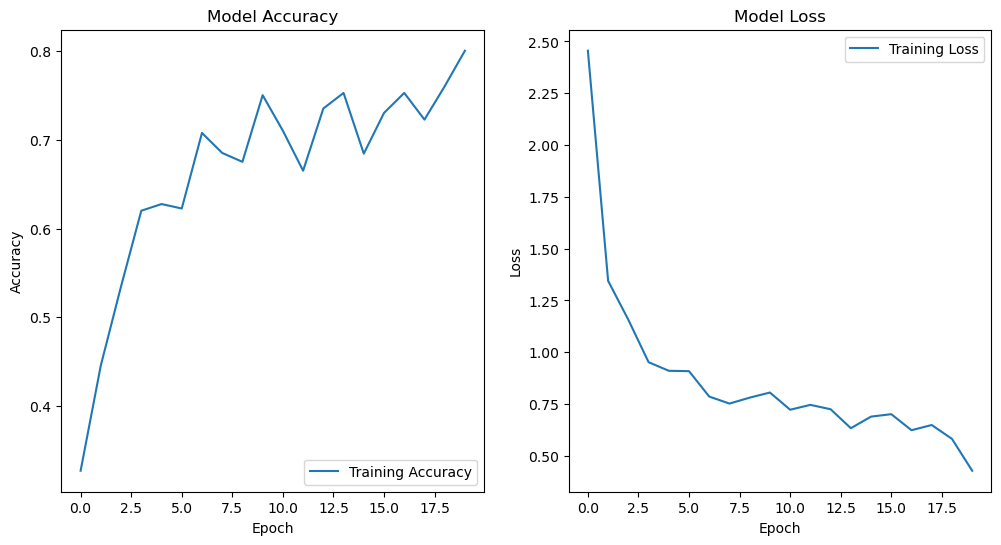

In [12]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

In [13]:
model.save('traffic_density_cnn_model.keras') # type: ignore
print("Model saved to traffic_density_cnn_model.keras")

Model saved to traffic_density_cnn_model.keras
